In [3]:
%pip install -q opencv-python tensorflow keras scikit-learn seaborn pandas numpy matplotlib pillow

print("Required packages installed successfully!")

Note: you may need to restart the kernel to use updated packages.
Required packages installed successfully!


## 1. Import Required Libraries

In [23]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print('Imports loaded successfully')

Imports loaded successfully


# Blood Cell Classification Model
## Complete Training Pipeline with Visualization and Predictions

## 2. Load and Explore Dataset

In [9]:
# Define blood cell types
wbcs = [
    'LYMPHOCYTE',  # 0
    'MONOCYTE',    # 1
    'NEUTROPHIL',  # 2
    'EOSINOPHIL',  # 3
]

# Define the path to the dataset
dataset_path = '../blood-cell-detection/dataset2-master/dataset2-master/images/'

# Check if paths exist
print("Checking dataset structure...")
for subset in ['TRAIN', 'TEST_SIMPLE', 'TEST']:
    path = os.path.join(dataset_path, subset)
    if os.path.exists(path):
        print(f"\n{subset} subset:")
        for cell_type in wbcs:
            cell_path = os.path.join(path, cell_type)
            if os.path.exists(cell_path):
                count = len(os.listdir(cell_path))
                print(f"  {cell_type}: {count} images")
    else:
        print(f"\n{subset} subset: NOT FOUND")

print("\nDataset path verified!")

Checking dataset structure...

TRAIN subset:
  LYMPHOCYTE: 2483 images
  MONOCYTE: 2478 images
  NEUTROPHIL: 2499 images
  EOSINOPHIL: 2497 images

TEST_SIMPLE subset:
  LYMPHOCYTE: 6 images
  MONOCYTE: 4 images
  NEUTROPHIL: 48 images
  EOSINOPHIL: 13 images

TEST subset:
  LYMPHOCYTE: 620 images
  MONOCYTE: 620 images
  NEUTROPHIL: 624 images
  EOSINOPHIL: 623 images

Dataset path verified!


## 3. Define Image Preprocessing Functions

In [10]:
def mask(path):
    """
    Apply masking to blood cell images to highlight the cells and remove background.
    """
    x = cv2.resize(cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB), (128, 128))
    m = np.ones(x.shape) * 255.0
    
    # Create mask for background (light pink pixels)
    m[(x[:, :, 0] >= 160) & (x[:, :, 1] >= 140) & (x[:, :, 2] >= 140)] = [0.0, 0.0, 0.0]
    
    # Dilate mask to remove noise
    kernel = np.ones((3, 3), dtype=np.uint8)
    m = cv2.dilate(m, kernel, iterations=2)
    
    # Apply mask to image
    return cv2.bitwise_and(x, np.array(m, np.uint8))

def get_images(path):
    """
    Load and preprocess images from the dataset directory.
    """
    X = []
    y = []
    
    for n, wbc_type in enumerate(wbcs):
        cell_type_path = os.path.join(path, wbc_type)
        if os.path.exists(cell_type_path):
            for image_name in os.listdir(cell_type_path):
                image_path = os.path.join(cell_type_path, image_name)
                try:
                    masked_img = mask(image_path)
                    X.append(img_to_array(Image.fromarray(masked_img.astype('uint8'))))
                    y.append(n)
                except Exception as e:
                    print(f"Error loading {image_path}: {e}")
    
    return np.array(X), np.array(y)

print("Image preprocessing functions defined!")

Image preprocessing functions defined!


## 4. Load Dataset

In [11]:
# Load dataset - This may take a few minutes
print("Loading training data...")
X_train, y_train = get_images(os.path.join(dataset_path, 'TRAIN'))
print(f"Training data loaded: {X_train.shape}")

print("\nLoading validation data...")
X_valid, y_valid = get_images(os.path.join(dataset_path, 'TEST_SIMPLE'))
print(f"Validation data loaded: {X_valid.shape}")

print("\nLoading test data...")
X_test, y_test = get_images(os.path.join(dataset_path, 'TEST'))
print(f"Test data loaded: {X_test.shape}")

print("\nAll datasets loaded successfully!")

Loading training data...
Training data loaded: (9957, 128, 128, 3)

Loading validation data...
Validation data loaded: (71, 128, 128, 3)

Loading test data...
Test data loaded: (2487, 128, 128, 3)

All datasets loaded successfully!


## 5. Visualize Raw Dataset Samples

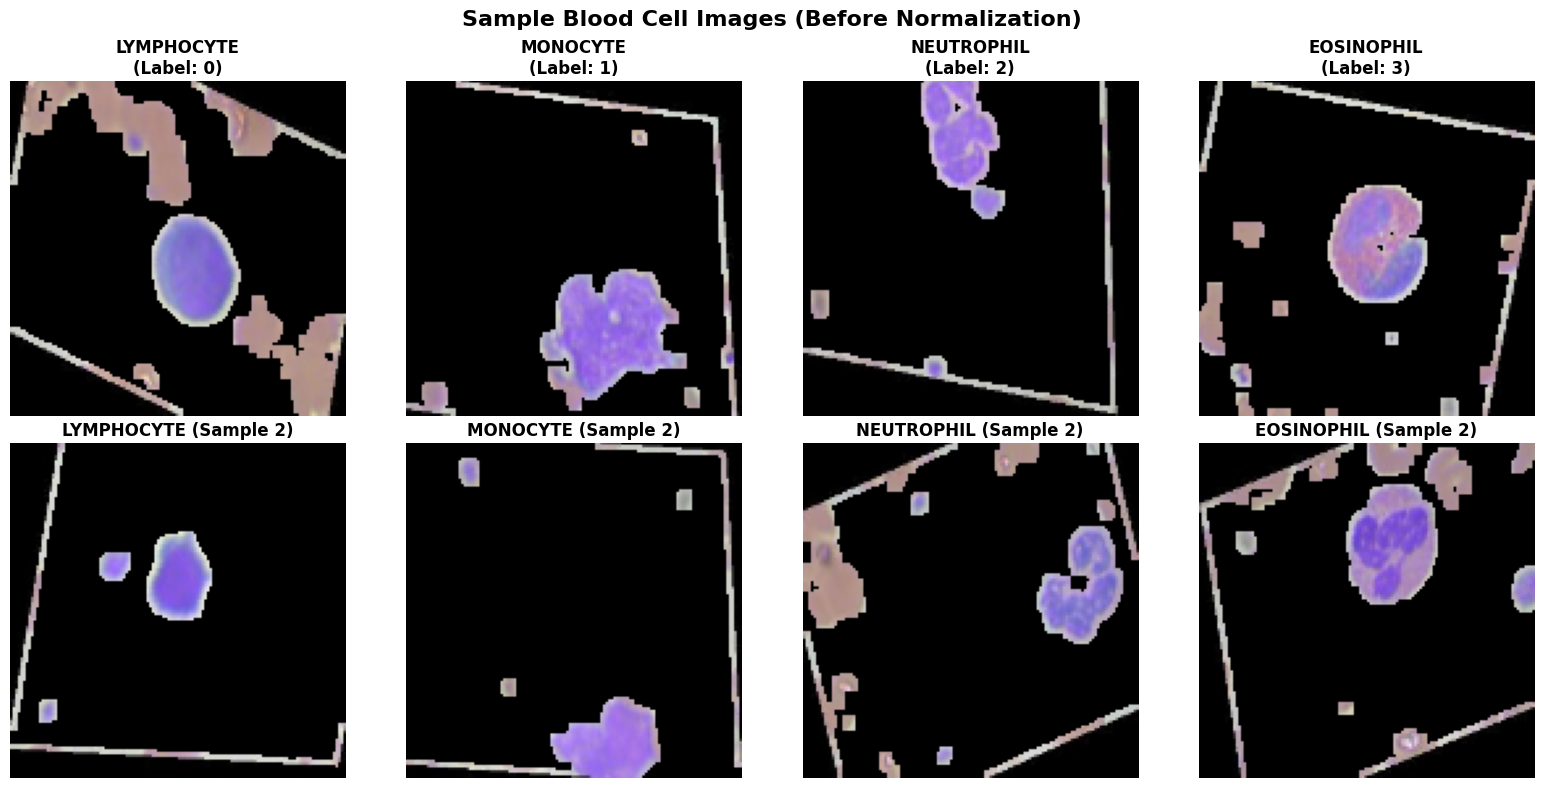

Sample images visualized!


In [12]:
# Visualize sample images before normalization
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Blood Cell Images (Before Normalization)', fontsize=16, fontweight='bold')

# Get one sample from each class
for idx, cell_type in enumerate(wbcs):
    # Find first image of this class
    class_indices = np.where(y_train == idx)[0]
    if len(class_indices) > 0:
        sample_idx = class_indices[0]
        img = X_train[sample_idx].astype('uint8')
        
        # First row: original images
        axes[0, idx].imshow(img)
        axes[0, idx].set_title(f'{cell_type}\n(Label: {idx})', fontweight='bold')
        axes[0, idx].axis('off')
        
        # Second row: different sample
        if len(class_indices) > 1:
            sample_idx_2 = class_indices[min(10, len(class_indices)-1)]
            img2 = X_train[sample_idx_2].astype('uint8')
            axes[1, idx].imshow(img2)
            axes[1, idx].set_title(f'{cell_type} (Sample 2)', fontweight='bold')
            axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

print("Sample images visualized!")

## 6. Dataset Statistics and Distribution

In [13]:
# Print dataset statistics
print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)

print(f"\nImage Dimensions: {X_train.shape[1]}x{X_train.shape[2]} pixels")
print(f"Channels: {X_train.shape[3]}")

print(f"\nTraining Set: {X_train.shape[0]} images")
print(f"Validation Set: {X_valid.shape[0]} images")
print(f"Test Set: {X_test.shape[0]} images")
print(f"Total: {X_train.shape[0] + X_valid.shape[0] + X_test.shape[0]} images")

# Class distribution
print(f"\nClass Distribution (Training Set):")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for label, count in zip(unique_train, counts_train):
    print(f"  {wbcs[label]}: {count} images ({count/len(y_train)*100:.1f}%)")

print(f"\nClass Distribution (Validation Set):")
unique_valid, counts_valid = np.unique(y_valid, return_counts=True)
for label, count in zip(unique_valid, counts_valid):
    print(f"  {wbcs[label]}: {count} images ({count/len(y_valid)*100:.1f}%)")

print(f"\nClass Distribution (Test Set):")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for label, count in zip(unique_test, counts_test):
    print(f"  {wbcs[label]}: {count} images ({count/len(y_test)*100:.1f}%)")

print("\n" + "=" * 60)

DATASET STATISTICS

Image Dimensions: 128x128 pixels
Channels: 3

Training Set: 9957 images
Validation Set: 71 images
Test Set: 2487 images
Total: 12515 images

Class Distribution (Training Set):
  LYMPHOCYTE: 2483 images (24.9%)
  MONOCYTE: 2478 images (24.9%)
  NEUTROPHIL: 2499 images (25.1%)
  EOSINOPHIL: 2497 images (25.1%)

Class Distribution (Validation Set):
  LYMPHOCYTE: 6 images (8.5%)
  MONOCYTE: 4 images (5.6%)
  NEUTROPHIL: 48 images (67.6%)
  EOSINOPHIL: 13 images (18.3%)

Class Distribution (Test Set):
  LYMPHOCYTE: 620 images (24.9%)
  MONOCYTE: 620 images (24.9%)
  NEUTROPHIL: 624 images (25.1%)
  EOSINOPHIL: 623 images (25.1%)



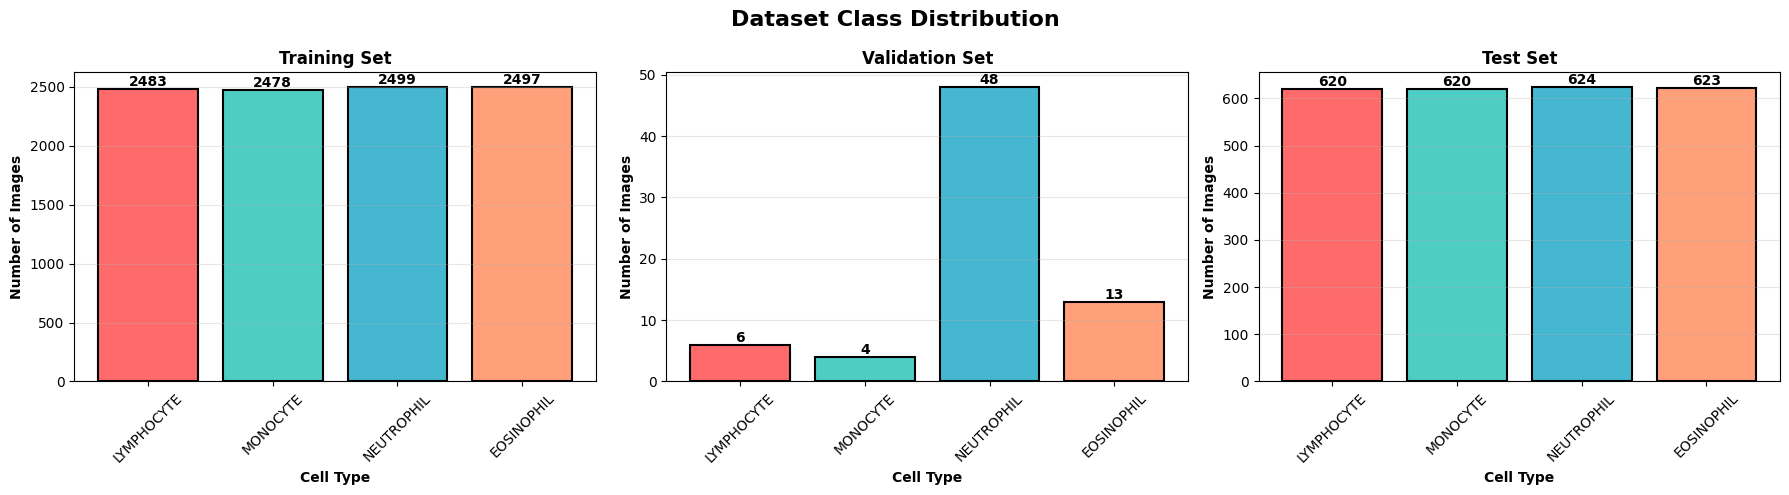

Dataset distribution visualized!


In [14]:
# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dataset Class Distribution', fontsize=16, fontweight='bold')

datasets = [
    (y_train, 'Training Set', counts_train),
    (y_valid, 'Validation Set', counts_valid),
    (y_test, 'Test Set', counts_test)
]

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for idx, (y_data, title, counts) in enumerate(datasets):
    ax = axes[idx]
    bars = ax.bar(wbcs, counts, color=colors, edgecolor='black', linewidth=1.5)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('Number of Images', fontweight='bold')
    ax.set_xlabel('Cell Type', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold')
    
    # Rotate x labels
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Dataset distribution visualized!")

## 7. Preprocess and Normalize Data

In [15]:
# Normalize pixel values to [0, 1]
X_train = X_train / 255.0
X_valid = X_valid / 255.0
X_test = X_test / 255.0

print("Image normalization complete!")
print(f"X_train range: [{X_train.min():.2f}, {X_train.max():.2f}]")
print(f"X_valid range: [{X_valid.min():.2f}, {X_valid.max():.2f}]")
print(f"X_test range: [{X_test.min():.2f}, {X_test.max():.2f}]")

# Convert labels to one-hot encoding
y_train_encoded = to_categorical(y_train, num_classes=len(wbcs))
y_valid_encoded = to_categorical(y_valid, num_classes=len(wbcs))
y_test_encoded = to_categorical(y_test, num_classes=len(wbcs))

print("\nLabels converted to one-hot encoding!")
print(f"y_train shape: {y_train_encoded.shape}")
print(f"y_valid shape: {y_valid_encoded.shape}")
print(f"y_test shape: {y_test_encoded.shape}")

Image normalization complete!
X_train range: [0.00, 1.00]
X_valid range: [0.00, 1.00]
X_test range: [0.00, 1.00]

Labels converted to one-hot encoding!
y_train shape: (9957, 4)
y_valid shape: (71, 4)
y_test shape: (2487, 4)


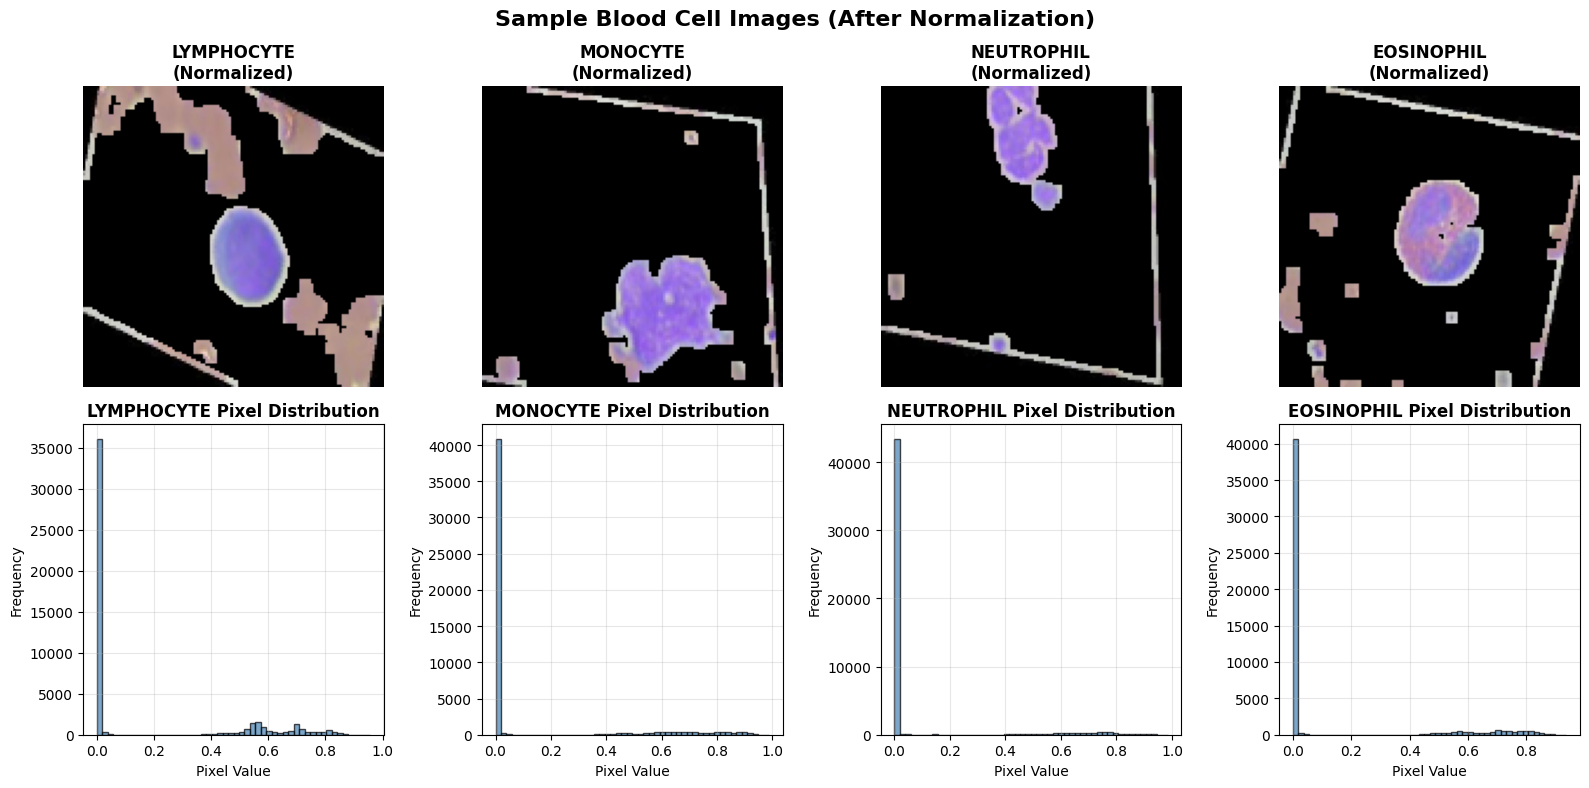

Preprocessed data visualized!


In [16]:
# Visualize normalized images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Blood Cell Images (After Normalization)', fontsize=16, fontweight='bold')

for idx, cell_type in enumerate(wbcs):
    class_indices = np.where(y_train == idx)[0]
    if len(class_indices) > 0:
        sample_idx = class_indices[0]
        img = X_train[sample_idx]
        
        axes[0, idx].imshow(img)
        axes[0, idx].set_title(f'{cell_type}\n(Normalized)', fontweight='bold')
        axes[0, idx].axis('off')
        
        # Histogram of pixel values
        axes[1, idx].hist(img.flatten(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
        axes[1, idx].set_title(f'{cell_type} Pixel Distribution', fontweight='bold')
        axes[1, idx].set_ylabel('Frequency')
        axes[1, idx].set_xlabel('Pixel Value')
        axes[1, idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Preprocessed data visualized!")

## 8. Build CNN Model

In [19]:
# Build a CNN model tuned for faster training on CPU
def create_model():
    """
    Create a compact CNN for blood cell classification.
    """
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(128, 128, 3)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.3),

        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.3),

        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(len(wbcs), activation='softmax')
    ])
    return model

model = create_model()

print('Model Architecture:')
print('=' * 70)
model.summary()
print('=' * 70)

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,586,948 (17.50 MB)

 Trainable params: 4,585,476 (17.49 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [20]:
# Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel compiled successfully!")
print(f"Optimizer: Adam (learning_rate=0.001)")
print(f"Loss: categorical_crossentropy")
print(f"Metrics: accuracy")


Model compiled successfully!
Optimizer: Adam (learning_rate=0.001)
Loss: categorical_crossentropy
Metrics: accuracy


## 9. Train the Model

In [21]:
# Define callbacks
callbacks = [
    # Save best model based on validation accuracy
    ModelCheckpoint(
        'blood_cell_model_best.h5',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    # Early stopping to prevent overfitting
    EarlyStopping(
        monitor='val_accuracy',
        mode='max',
        patience=10,
        verbose=1,
        restore_best_weights=True
    ),
    # Reduce learning rate when validation accuracy plateaus
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks configured!")
print("- ModelCheckpoint: Saves best model based on validation accuracy")
print("- EarlyStopping: Stops training if no improvement for 10 epochs")
print("- ReduceLROnPlateau: Reduces learning rate by 0.5x when plateaued")

Callbacks configured!
- ModelCheckpoint: Saves best model based on validation accuracy
- EarlyStopping: Stops training if no improvement for 10 epochs
- ReduceLROnPlateau: Reduces learning rate by 0.5x when plateaued


In [24]:
# Train the model
print('\nStarting model training...')
print('=' * 70)

# Build a stratified validation split from training data for robust monitoring
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train_encoded,
    test_size=0.15,
    random_state=42,
    stratify=y_train
)

print(f'Train split for fitting: {X_tr.shape[0]}')
print(f'Validation split for fitting: {X_val.shape[0]}')

history = model.fit(
    X_tr, y_tr,
    batch_size=32,
    epochs=25,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

print('=' * 70)
print('Training completed!')

# Store history for visualization
train_loss = history.history['loss']
train_accuracy = history.history['accuracy']
val_loss = history.history['val_loss']
val_accuracy = history.history['val_accuracy']


Starting model training...
Train split for fitting: 8463
Validation split for fitting: 1494
Epoch 1/25
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.3203 - loss: 1.9227
Epoch 1: val_accuracy improved from None to 0.24900, saving model to blood_cell_model_best.h5



Epoch 1: finished saving model to blood_cell_model_best.h5
265/265 ━━━━━━━━━━━━━━━━━━━━ 109s 397ms/step - accuracy: 0.3890 - loss: 1.5466 - val_accuracy: 0.2490 - val_loss: 26.1219 - learning_rate: 0.0010
Epoch 2/25
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.6495 - loss: 0.8646
Epoch 2: val_accuracy did not improve from 0.24900
265/265 ━━━━━━━━━━━━━━━━━━━━ 103s 389ms/step - accuracy: 0.6923 - loss: 0.7604 - val_accuracy: 0.2490 - val_loss: 79.1031 - learning_rate: 0.0010
Epoch 3/25
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.7768 - loss: 0.5735
Epoch 3: val_accuracy improved from 0.24900 to 0.24967, saving model to blood_cell_model_best.h5



Epoch 3: finished saving model to blood_cell_model_best.h5
265/265 ━━━━━━━━━━━━━━━━━━━━ 99s 374ms/step - accuracy: 0.7900 - loss: 0.5344 - val_accuracy: 0.2497 - val_loss: 41.5132 - learning_rate: 0.0010
Epoch 4/25
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.8376 - loss: 0.4211
Epoch 4: val_accuracy improved from 0.24967 to 0.31325, saving model to blood_cell_model_best.h5



Epoch 4: finished saving model to blood_cell_model_best.h5
265/265 ━━━━━━━━━━━━━━━━━━━━ 112s 422ms/step - accuracy: 0.8426 - loss: 0.3994 - val_accuracy: 0.3133 - val_loss: 28.8502 - learning_rate: 0.0010
Epoch 5/25
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.8613 - loss: 0.3535
Epoch 5: val_accuracy did not improve from 0.31325
265/265 ━━━━━━━━━━━━━━━━━━━━ 100s 378ms/step - accuracy: 0.8645 - loss: 0.3339 - val_accuracy: 0.2490 - val_loss: 37.1533 - learning_rate: 0.0010
Epoch 6/25
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.8876 - loss: 0.2939
Epoch 6: val_accuracy did not improve from 0.31325
265/265 ━━━━━━━━━━━━━━━━━━━━ 103s 389ms/step - accuracy: 0.8896 - loss: 0.2817 - val_accuracy: 0.2858 - val_loss: 12.4390 - learning_rate: 0.0010
Epoch 7/25
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.9023 - loss: 0.2526
Epoch 7: val_accuracy did not improve from 0.31325
265/265 ━━━━━━━━━━━━━━━━━━━━ 102s 386ms/step - accuracy: 0.9048 - loss: 0.2418 - val_


Epoch 8: finished saving model to blood_cell_model_best.h5
265/265 ━━━━━━━━━━━━━━━━━━━━ 107s 405ms/step - accuracy: 0.9192 - loss: 0.2030 - val_accuracy: 0.5348 - val_loss: 2.3279 - learning_rate: 0.0010
Epoch 9/25
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.9329 - loss: 0.1697
Epoch 9: val_accuracy did not improve from 0.53481
265/265 ━━━━━━━━━━━━━━━━━━━━ 95s 358ms/step - accuracy: 0.9347 - loss: 0.1655 - val_accuracy: 0.3139 - val_loss: 13.3033 - learning_rate: 0.0010
Epoch 10/25
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.9285 - loss: 0.1859
Epoch 10: val_accuracy did not improve from 0.53481
265/265 ━━━━━━━━━━━━━━━━━━━━ 94s 354ms/step - accuracy: 0.9289 - loss: 0.1800 - val_accuracy: 0.3340 - val_loss: 27.7819 - learning_rate: 0.0010
Epoch 11/25
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9399 - loss: 0.1564
Epoch 11: val_accuracy did not improve from 0.53481
265/265 ━━━━━━━━━━━━━━━━━━━━ 122s 462ms/step - accuracy: 0.9456 - loss: 0.1407 - val


Epoch 13: finished saving model to blood_cell_model_best.h5
265/265 ━━━━━━━━━━━━━━━━━━━━ 95s 359ms/step - accuracy: 0.9605 - loss: 0.1017 - val_accuracy: 0.8708 - val_loss: 0.5237 - learning_rate: 0.0010
Epoch 14/25
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.9410 - loss: 0.1610
Epoch 14: val_accuracy did not improve from 0.87082
265/265 ━━━━━━━━━━━━━━━━━━━━ 100s 379ms/step - accuracy: 0.9391 - loss: 0.1602 - val_accuracy: 0.3681 - val_loss: 9.9159 - learning_rate: 0.0010
Epoch 15/25
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.9410 - loss: 0.1607
Epoch 15: val_accuracy did not improve from 0.87082
265/265 ━━━━━━━━━━━━━━━━━━━━ 106s 398ms/step - accuracy: 0.9500 - loss: 0.1371 - val_accuracy: 0.2490 - val_loss: 96.2829 - learning_rate: 0.0010
Epoch 16/25
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 508ms/step - accuracy: 0.9652 - loss: 0.0892
Epoch 16: val_accuracy did not improve from 0.87082
265/265 ━━━━━━━━━━━━━━━━━━━━ 176s 527ms/step - accuracy: 0.9664 - loss: 0.0891 - 

## 10. Visualize Training History

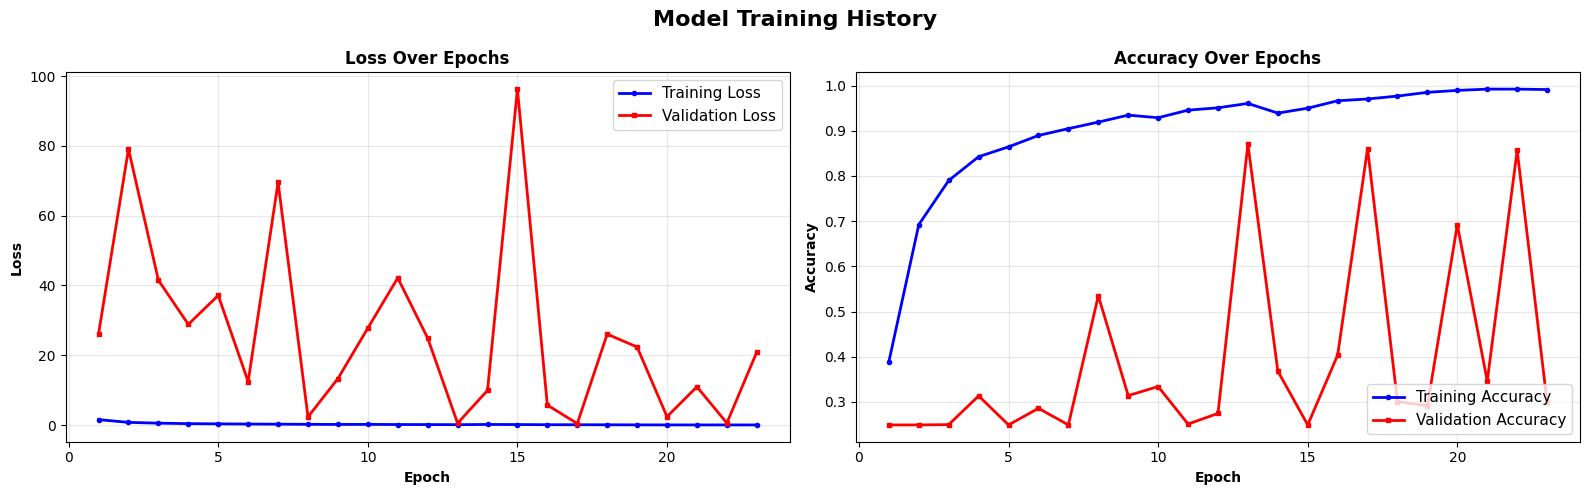

Training history visualized!

Best Training Accuracy: 0.9922
Best Validation Accuracy: 0.8708
Final Training Loss: 0.0258
Final Validation Loss: 20.8958


In [25]:
# Create visualization of training history
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Model Training History', fontsize=16, fontweight='bold')

epochs_range = range(1, len(train_loss) + 1)

# Loss plot
ax1 = axes[0]
ax1.plot(epochs_range, train_loss, 'b-', label='Training Loss', linewidth=2, marker='o', markersize=3)
ax1.plot(epochs_range, val_loss, 'r-', label='Validation Loss', linewidth=2, marker='s', markersize=3)
ax1.set_xlabel('Epoch', fontweight='bold')
ax1.set_ylabel('Loss', fontweight='bold')
ax1.set_title('Loss Over Epochs', fontweight='bold')
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2 = axes[1]
ax2.plot(epochs_range, train_accuracy, 'b-', label='Training Accuracy', linewidth=2, marker='o', markersize=3)
ax2.plot(epochs_range, val_accuracy, 'r-', label='Validation Accuracy', linewidth=2, marker='s', markersize=3)
ax2.set_xlabel('Epoch', fontweight='bold')
ax2.set_ylabel('Accuracy', fontweight='bold')
ax2.set_title('Accuracy Over Epochs', fontweight='bold')
ax2.legend(loc='lower right', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Training history visualized!")
print(f"\nBest Training Accuracy: {max(train_accuracy):.4f}")
print(f"Best Validation Accuracy: {max(val_accuracy):.4f}")
print(f"Final Training Loss: {train_loss[-1]:.4f}")
print(f"Final Validation Loss: {val_loss[-1]:.4f}")

## 11. Model Evaluation on Test Set

In [26]:
# Load the best model
from tensorflow.keras.models import load_model
best_model = load_model('blood_cell_model_best.h5')

# Evaluate on test set
print("\nEvaluating model on test set...")
test_loss, test_accuracy = best_model.evaluate(X_test, y_test_encoded, verbose=0)

print("\n" + "=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("=" * 60)

# Make predictions on test set
y_pred_probs = best_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Calculate per-class metrics
print("\nPer-Class Metrics:")
print("-" * 60)
for i, cell_type in enumerate(wbcs):
    class_mask = (y_test == i)
    class_acc = accuracy_score(y_test[class_mask], y_pred[class_mask])
    class_count = np.sum(class_mask)
    print(f"{cell_type:15} | Samples: {class_count:4} | Accuracy: {class_acc:.4f} ({class_acc*100:.2f}%)")
print("-" * 60)


Evaluating model on test set...

TEST SET EVALUATION
Test Loss: 1.1976
Test Accuracy: 0.7298 (72.98%)

Per-Class Metrics:
------------------------------------------------------------
LYMPHOCYTE      | Samples:  620 | Accuracy: 0.7645 (76.45%)
MONOCYTE        | Samples:  620 | Accuracy: 0.6887 (68.87%)
NEUTROPHIL      | Samples:  624 | Accuracy: 0.6506 (65.06%)
EOSINOPHIL      | Samples:  623 | Accuracy: 0.8154 (81.54%)
------------------------------------------------------------


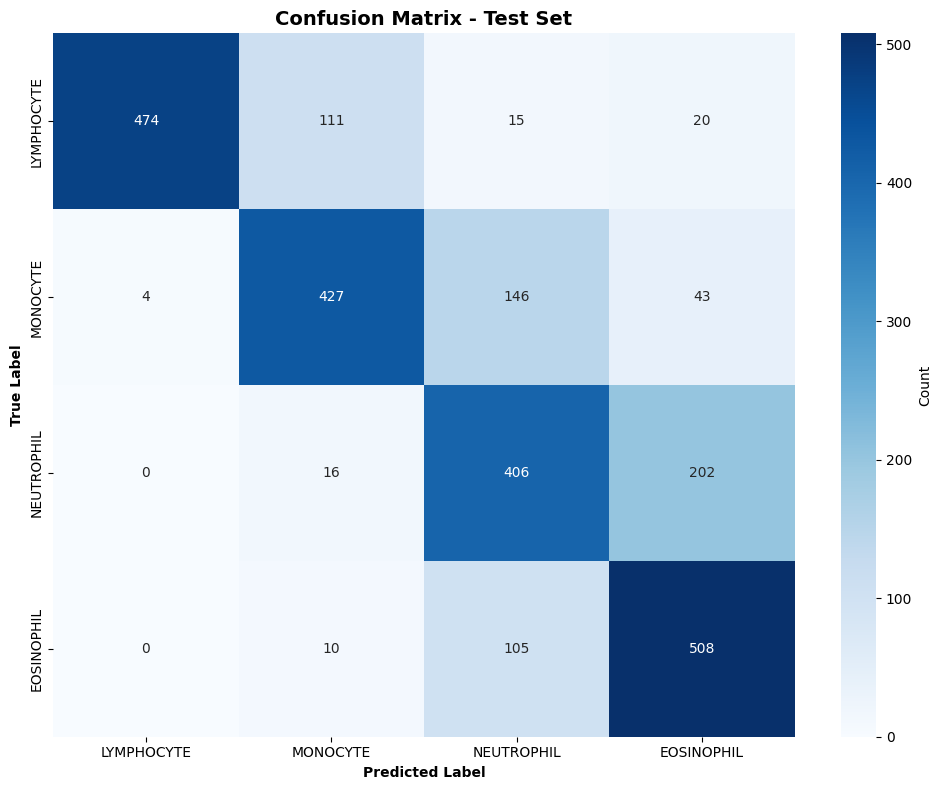

Confusion matrix visualized!


In [27]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=wbcs, yticklabels=wbcs,
            cbar_kws={'label': 'Count'}, ax=ax)
ax.set_ylabel('True Label', fontweight='bold')
ax.set_xlabel('Predicted Label', fontweight='bold')
ax.set_title('Confusion Matrix - Test Set', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("Confusion matrix visualized!")

In [28]:
# Detailed Classification Report
print("\nDetailed Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=wbcs))
print("=" * 60)


Detailed Classification Report:
              precision    recall  f1-score   support

  LYMPHOCYTE       0.99      0.76      0.86       620
    MONOCYTE       0.76      0.69      0.72       620
  NEUTROPHIL       0.60      0.65      0.63       624
  EOSINOPHIL       0.66      0.82      0.73       623

    accuracy                           0.73      2487
   macro avg       0.75      0.73      0.73      2487
weighted avg       0.75      0.73      0.73      2487



## 12. Visualize Model Predictions

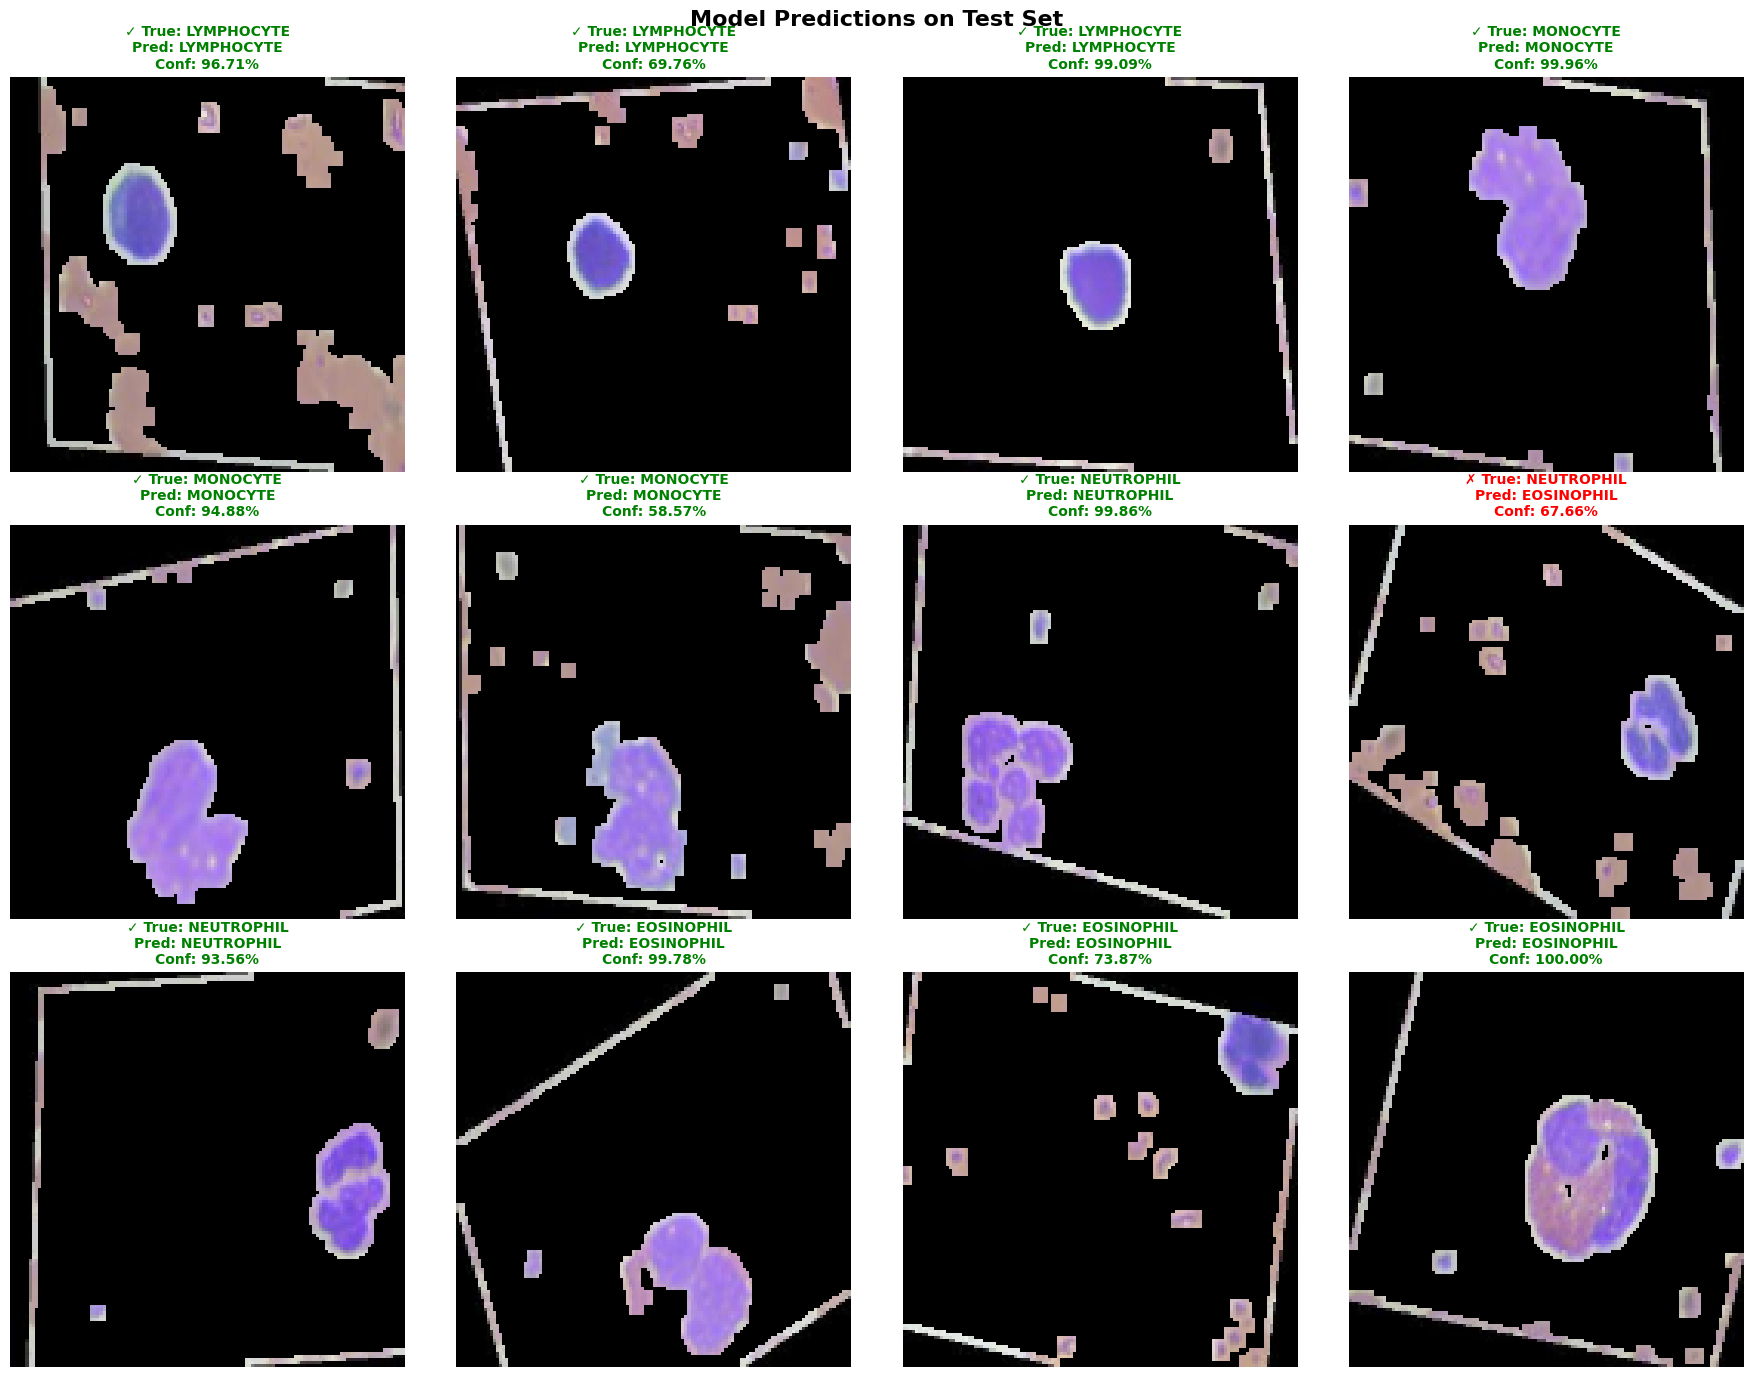

Predictions visualized!


In [29]:
# Visualize predictions on test set
num_samples = 12
fig, axes = plt.subplots(3, 4, figsize=(18, 14))
fig.suptitle('Model Predictions on Test Set', fontsize=16, fontweight='bold')

# Randomly select samples from each class
sample_indices = []
for class_idx in range(len(wbcs)):
    class_indices = np.where(y_test == class_idx)[0]
    # Get 3 random samples from each class
    selected = np.random.choice(class_indices, size=min(3, len(class_indices)), replace=False)
    sample_indices.extend(selected)

sample_indices = sample_indices[:num_samples]

for plot_idx, sample_idx in enumerate(sample_indices):
    ax = axes[plot_idx // 4, plot_idx % 4]
    
    # Get image and predictions
    image = X_test[sample_idx]
    true_label = y_test[sample_idx]
    pred_label = y_pred[sample_idx]
    confidence = y_pred_probs[sample_idx][pred_label]
    
    # Display image
    ax.imshow(image)
    
    # Create title with prediction info
    true_name = wbcs[true_label]
    pred_name = wbcs[pred_label]
    
    if true_label == pred_label:
        title_color = 'green'
        title_text = f'✓ True: {true_name}\nPred: {pred_name}\nConf: {confidence:.2%}'
    else:
        title_color = 'red'
        title_text = f'✗ True: {true_name}\nPred: {pred_name}\nConf: {confidence:.2%}'
    
    ax.set_title(title_text, fontweight='bold', color=title_color, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("Predictions visualized!")

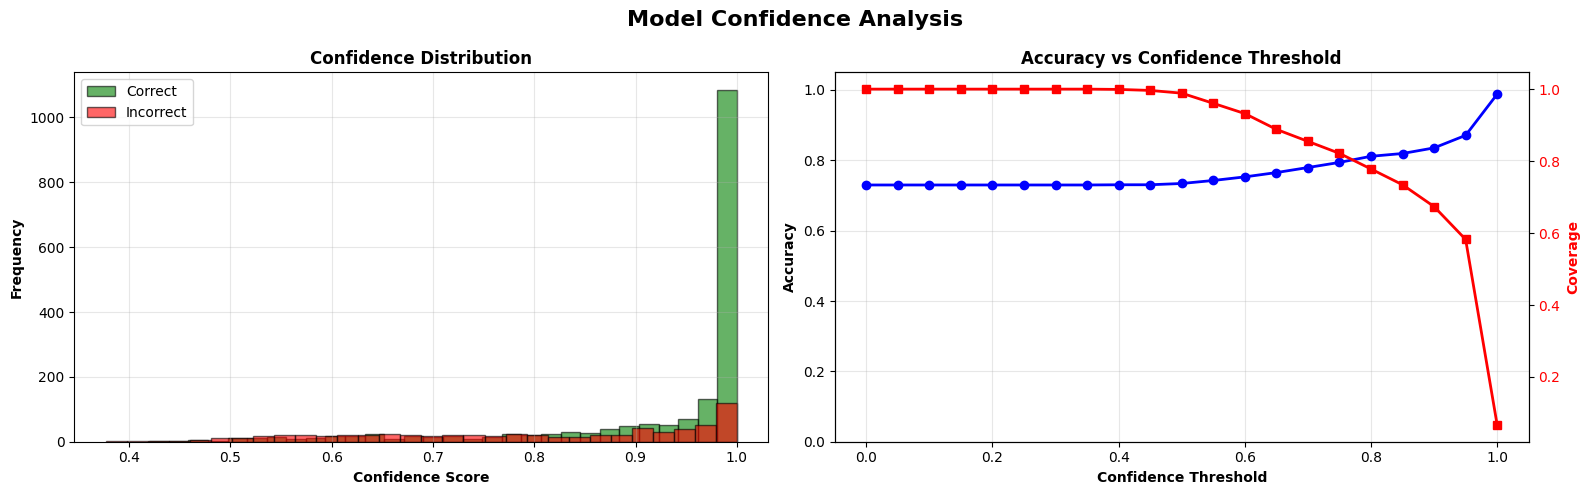


Confidence Statistics:
Mean confidence (correct): 0.9292
Mean confidence (incorrect): 0.8043
Overall mean confidence: 0.8955


In [30]:
# Visualize confidence distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Model Confidence Analysis', fontsize=16, fontweight='bold')

# Get max confidence for each prediction
max_confidences = np.max(y_pred_probs, axis=1)

# Correct vs Incorrect predictions
correct_mask = (y_test == y_pred)
correct_confidences = max_confidences[correct_mask]
incorrect_confidences = max_confidences[~correct_mask]

# Plot 1: Histogram of confidences
ax1 = axes[0]
ax1.hist(correct_confidences, bins=30, alpha=0.6, label='Correct', color='green', edgecolor='black')
ax1.hist(incorrect_confidences, bins=30, alpha=0.6, label='Incorrect', color='red', edgecolor='black')
ax1.set_xlabel('Confidence Score', fontweight='bold')
ax1.set_ylabel('Frequency', fontweight='bold')
ax1.set_title('Confidence Distribution', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot 2: Accuracy by confidence threshold
ax2 = axes[1]
confidence_thresholds = np.linspace(0, 1, 21)
accuracies_by_threshold = []
coverage_by_threshold = []

for threshold in confidence_thresholds:
    mask = max_confidences >= threshold
    if np.sum(mask) > 0:
        acc = np.mean(y_test[mask] == y_pred[mask])
        coverage = np.sum(mask) / len(y_test)
        accuracies_by_threshold.append(acc)
        coverage_by_threshold.append(coverage)
    else:
        accuracies_by_threshold.append(0)
        coverage_by_threshold.append(0)

ax2.plot(confidence_thresholds, accuracies_by_threshold, 'b-', linewidth=2, marker='o', label='Accuracy')
ax2.set_xlabel('Confidence Threshold', fontweight='bold')
ax2.set_ylabel('Accuracy', fontweight='bold')
ax2.set_title('Accuracy vs Confidence Threshold', fontweight='bold')
ax2.grid(alpha=0.3)
ax2.set_ylim([0, 1.05])

# Add secondary axis for coverage
ax2_sec = ax2.twinx()
ax2_sec.plot(confidence_thresholds, coverage_by_threshold, 'r-', linewidth=2, marker='s', label='Coverage')
ax2_sec.set_ylabel('Coverage', fontweight='bold', color='red')
ax2_sec.tick_params(axis='y', labelcolor='red')

plt.tight_layout()
plt.show()

print(f"\nConfidence Statistics:")
print(f"Mean confidence (correct): {np.mean(correct_confidences):.4f}")
print(f"Mean confidence (incorrect): {np.mean(incorrect_confidences):.4f}")
print(f"Overall mean confidence: {np.mean(max_confidences):.4f}")

## 13. Save the Model

In [33]:
# Save the model in multiple formats for flexibility
print('Saving model...')
print('=' * 60)

# 1. Save best model in modern Keras format
best_model.save('blood_cell_model_best.keras')
print('Saved: blood_cell_model_best.keras')

# 2. Save model architecture and weights separately
model_json = best_model.to_json()
with open('blood_cell_model_architecture.json', 'w') as json_file:
    json_file.write(model_json)
print('Saved: blood_cell_model_architecture.json')

best_model.save_weights('blood_cell_model.weights.h5')
print('Saved: blood_cell_model.weights.h5')

# 3. Save TensorFlow SavedModel directory
import tensorflow as tf
tf.saved_model.save(best_model, 'blood_cell_model_savedmodel')
print('Saved: blood_cell_model_savedmodel/')

# 4. Save model information and preprocessing parameters
import json

model_info = {
    'class_names': wbcs,
    'image_size': 128,
    'num_classes': len(wbcs),
    'test_accuracy': float(test_accuracy),
    'test_loss': float(test_loss),
    'input_shape': [128, 128, 3],
    'normalization': {
        'method': 'min-max',
        'min': 0.0,
        'max': 1.0
    }
}

with open('blood_cell_model_info.json', 'w') as f:
    json.dump(model_info, f, indent=4)
print('Saved: blood_cell_model_info.json')

print('\n' + '=' * 60)
print('All model files saved successfully!')
print('=' * 60)

Saving model...
Saved: blood_cell_model_best.keras
Saved: blood_cell_model_architecture.json
Saved: blood_cell_model.weights.h5
INFO:tensorflow:Assets written to: blood_cell_model_savedmodel\assets


INFO:tensorflow:Assets written to: blood_cell_model_savedmodel\assets


Saved: blood_cell_model_savedmodel/
Saved: blood_cell_model_info.json

All model files saved successfully!


In [34]:
# Create a summary report
print('\n' + '=' * 70)
print('BLOOD CELL CLASSIFICATION MODEL - FINAL SUMMARY')
print('=' * 70)

print('\nDATASET SUMMARY:')
print(f'  - Training samples: {len(X_train)}')
print(f'  - Validation samples: {len(X_valid)}')
print(f'  - Test samples: {len(X_test)}')
print('  - Image size: 128x128 pixels')
print('  - Channels: 3 (RGB)')
print(f'  - Classes: {len(wbcs)} ({", ".join(wbcs)})')

print('\nMODEL ARCHITECTURE:')
print('  - Type: Convolutional Neural Network (CNN)')
print('  - Convolutional blocks: 4')
print(f'  - Total parameters: {best_model.count_params():,}')

print('\nPERFORMANCE METRICS:')
print(f'  - Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')
print(f'  - Test Loss: {test_loss:.4f}')
print(f'  - Best Validation Accuracy: {max(val_accuracy):.4f}')

print('\nPER-CLASS PERFORMANCE:')
for i, cell_type in enumerate(wbcs):
    class_mask = (y_test == i)
    class_acc = accuracy_score(y_test[class_mask], y_pred[class_mask])
    print(f'  - {cell_type:15}: {class_acc:.4f} ({class_acc*100:.2f}%)')

print('\nSAVED FILES:')
print('  - blood_cell_model_best.keras (complete model, recommended)')
print('  - blood_cell_model_best.h5 (legacy checkpoint)')
print('  - blood_cell_model_savedmodel/ (TensorFlow SavedModel)')
print('  - blood_cell_model_architecture.json (architecture)')
print('  - blood_cell_model.weights.h5 (weights)')
print('  - blood_cell_model_info.json (metadata)')

print('\n' + '=' * 70)
print('MODEL TRAINING AND EVALUATION COMPLETE')
print('=' * 70)
print('\nNext step later: Build a web app (Flask/FastAPI/Streamlit) for image upload and prediction.')


BLOOD CELL CLASSIFICATION MODEL - FINAL SUMMARY

DATASET SUMMARY:
  - Training samples: 9957
  - Validation samples: 71
  - Test samples: 2487
  - Image size: 128x128 pixels
  - Channels: 3 (RGB)
  - Classes: 4 (LYMPHOCYTE, MONOCYTE, NEUTROPHIL, EOSINOPHIL)

MODEL ARCHITECTURE:
  - Type: Convolutional Neural Network (CNN)
  - Convolutional blocks: 4
  - Total parameters: 4,586,948

PERFORMANCE METRICS:
  - Test Accuracy: 0.7298 (72.98%)
  - Test Loss: 1.1976
  - Best Validation Accuracy: 0.8708

PER-CLASS PERFORMANCE:
  - LYMPHOCYTE     : 0.7645 (76.45%)
  - MONOCYTE       : 0.6887 (68.87%)
  - NEUTROPHIL     : 0.6506 (65.06%)
  - EOSINOPHIL     : 0.8154 (81.54%)

SAVED FILES:
  - blood_cell_model_best.keras (complete model, recommended)
  - blood_cell_model_best.h5 (legacy checkpoint)
  - blood_cell_model_savedmodel/ (TensorFlow SavedModel)
  - blood_cell_model_architecture.json (architecture)
  - blood_cell_model.weights.h5 (weights)
  - blood_cell_model_info.json (metadata)

MODEL 